In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
def plot_parallel_mapping(
    ax, func, title, x_range=(-1, 1), num_points=9, x_label="x_in", y_label="x_out"
):
    """
    Plots a 1D parallel coordinate mapping diagram on the given axis.
    """
    # FIX 1: Correctly unpack the tuple elements for the linspace boundary coordinates
    x_in = np.linspace(x_range, x_range[1], num_points)
    x_out = func(x_in)

    # Clean up axes for a minimalistic presentation
    ax.set_title(title, fontsize=12, fontweight="bold", pad=15)
    ax.set_yticks([])
    ax.set_xticks([])

    # Hide the bounding box (spines)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Draw horizontal axis lines representing input and output dimensions
    ax.axhline(0, color="black", lw=1.5, zorder=1)
    ax.axhline(1, color="black", lw=1.5, zorder=1)

    # Generate an accessible color palette so each individual point can be tracked
    colors = sns.color_palette("colorblind", num_points)

    # Draw mapping lines with directional arrows
    for i in range(num_points):
        color = colors[i]
        # Draw arrows from bottom (y=0) to top (y=1)
        ax.annotate(
            "",
            xy=(x_out[i], 1),
            xytext=(x_in[i], 0),
            arrowprops=dict(
                arrowstyle="->", color=color, lw=1.5, alpha=0.8, shrinkA=0, shrinkB=2
            ),
        )

    # Plot point markers on both axes to illustrate density changes (e.g. ReLU collapses)
    ax.scatter(
        x_in,
        np.zeros_like(x_in),
        color=colors,
        s=40,
        zorder=5,
        edgecolor="black",
        linewidth=0.5,
    )
    ax.scatter(
        x_out,
        np.ones_like(x_out),
        color=colors,
        s=40,
        zorder=5,
        edgecolor="black",
        linewidth=0.5,
    )

    # FIX 2: Calculate the margin using tuple values
    margin = (x_range[1] - x_range) * 0.15

    # FIX 3: Shift the text labels to the left of the minimum value x_range
    ax.text(
        x_range - margin,
        0,
        x_label,
        fontsize=11,
        fontweight="bold",
        va="center",
        ha="right",
    )
    ax.text(
        x_range - margin,
        1,
        y_label,
        fontsize=11,
        fontweight="bold",
        va="center",
        ha="right",
    )

    # Draw ticks and numeric labels on both axes manually
    tick_length = 0.04
    # FIX 4: Correctly space tick generation
    ticks = np.linspace(x_range, x_range[1], 5)
    for tick in ticks:
        # Bottom (Input) ticks
        ax.plot([tick, tick], [-tick_length, tick_length], color="black", lw=1)
        ax.text(
            tick,
            -tick_length * 2,
            f"{tick:.1f}",
            ha="center",
            va="top",
            fontsize=9,
            color="dimgray",
        )

        # Top (Output) ticks
        ax.plot([tick, tick], [1 - tick_length, 1 + tick_length], color="black", lw=1)
        ax.text(
            tick,
            1 + tick_length * 2,
            f"{tick:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="dimgray",
        )

    # FIX 5: Pad limit boundaries relative to the unpacked boundaries
    ax.set_xlim(x_range - margin * 1.5, x_range[1] + margin * 1.5)
    ax.set_ylim(-0.25, 1.25)


def main():
    # Set standard seaborn style for a clean canvas
    sns.set_theme(style="white")

    # Set up a 2x2 grid figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        "Data Transformations Plotted as Parallel Coordinate Mappings",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    # 1. Linear Scaling: x_out = 2 * x_in
    plot_parallel_mapping(
        axes,
        lambda x: 2.0 * x,
        r"Linear Scaling Layer: $x_{\mathrm{out}} = 2 \cdot x_{\mathrm{in}}$"
        + "\n"
        + "(Expands/dilates the representation space)",
        x_range=(-1, 1),
        num_points=9,
    )

    # 2. Linear Scaling & Translation: x_out = (x_in + 1) / 2
    plot_parallel_mapping(
        axes[1],
        lambda x: (x + 1.0) / 2.0,
        r"Translation & Scale: $x_{\mathrm{out}} = \frac{x_{\mathrm{in}} + 1}{2}$"
        + "\n"
        + "(Shifts and squishes the representation space)",
        x_range=(-1, 1),
        num_points=9,
    )

    # 3. ReLU Activation: x_out = max(x_in, 0)
    plot_parallel_mapping(
        axes[1],
        lambda x: np.maximum(0, x),
        r"ReLU Activation: $x_{\mathrm{out}} = \max(x_{\mathrm{in}}, 0)$"
        + "\n"
        + "(Negative half-space collapses to a spike at 0)",
        x_range=(-1, 1),
        num_points=9,
    )

    # 4. Sigmoid Activation: x_out = 1 / (1 + e^-x_in)
    plot_parallel_mapping(
        axes[1],
        lambda x: 1.0 / (1.0 + np.exp(-x)),
        r"Sigmoid Activation: $x_{\mathrm{out}} = \sigma(x_{\mathrm{in}})$"
        + "\n"
        + "(Squeezes entire domain into bounded (0, 1) range)",
        x_range=(-5, 5),  # Expanded range to clearly show asymptotic plateauing
        num_points=9,
    )

    plt.tight_layout(pad=3.0)

    # Save the output image
    plt.savefig("parallel_mappings_grid.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(
        "Parallel coordinate mappings successfully saved as 'parallel_mappings_grid.png'!"
    )

In [ ]:
main()

Training Autoencoder...


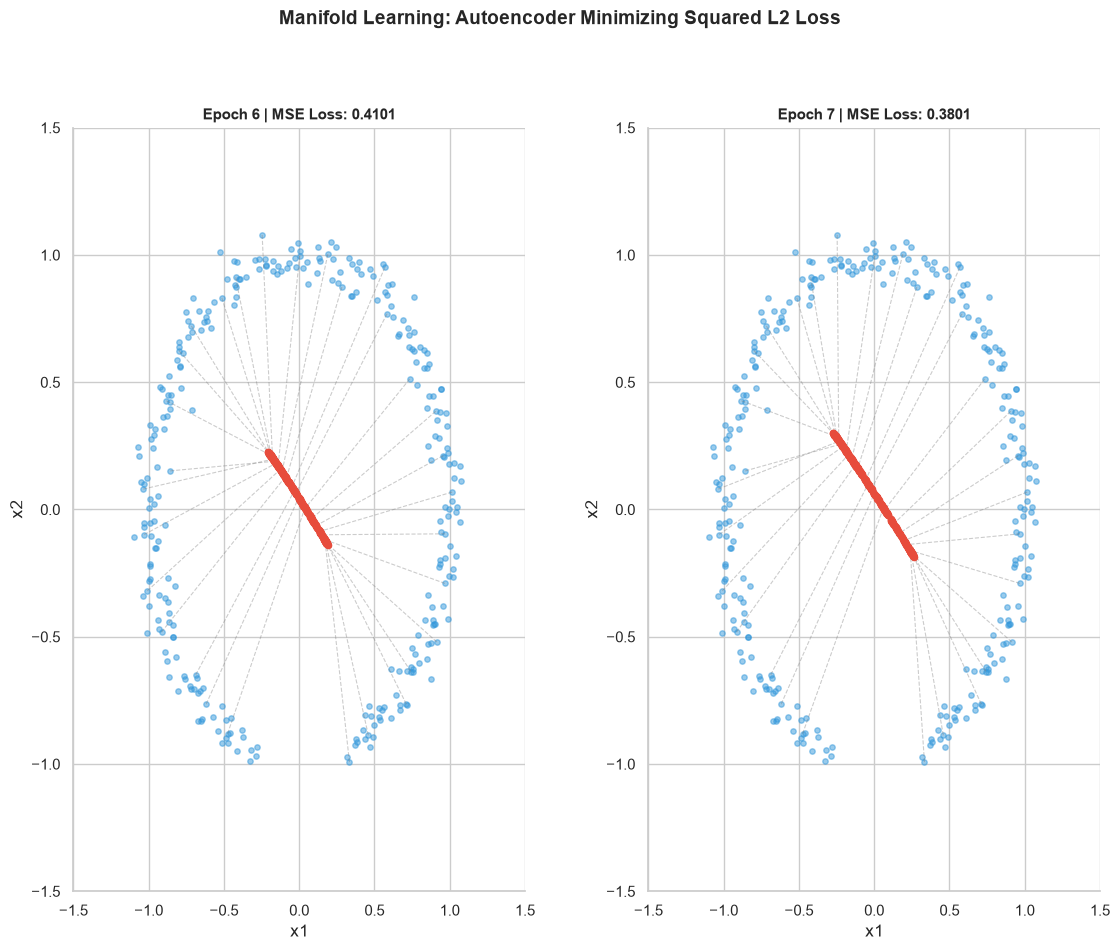

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

# 1. Generate synthetic curved 2D data
num_samples = 300
theta = np.linspace(-0.4 * np.pi, 1.4 * np.pi, num_samples)
noise_x = np.random.normal(0, 0.05, num_samples)
noise_y = np.random.normal(0, 0.05, num_samples)

x1 = np.cos(theta) + noise_x
x2 = np.sin(theta) + noise_y
X_np = np.stack([x1, x2], axis=1).astype(np.float32)
X_tensor = torch.from_numpy(X_np)


# 2. Define a Non-linear Autoencoder (2D -> 1D Bottleneck -> 2D)
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: Compresses 2D space down to a 1D coordinate (z)
        self.encoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 8),
            nn.Tanh(),
            nn.Linear(8, 1),  # 1D Bottleneck representation space
        )
        # Decoder: Maps the 1D coordinate back into the original 2D space
        self.decoder = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 16),
            nn.Tanh(),
            nn.Linear(16, 2),  # 2D reconstruction
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat


# 3. Model setup and optimizer
model = Autoencoder()
criterion = nn.MSELoss()  # Squared L2 reconstruction loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs_to_plot = [6, 7]
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes = axes.flatten()

print("Training Autoencoder...")
for epoch in range(1001):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    z, X_hat = model(X_tensor)
    loss = criterion(X_hat, X_tensor)

    # Backward pass and gradient step
    loss.backward()
    optimizer.step()

    # Plot state at milestones
    if epoch in epochs_to_plot:
        model.eval()
        with torch.no_grad():
            z_eval, X_hat_eval = model(X_tensor)
            recon_np = X_hat_eval.numpy()

            ax = axes[epochs_to_plot.index(epoch)]
            # Draw raw input data
            ax.scatter(
                X_np[:, 0],
                X_np[:, 1],
                color="#3498db",
                alpha=0.5,
                s=15,
                label="Original x",
            )
            # Draw reconstructions constrained to the learned 1D bottleneck manifold
            ax.scatter(
                recon_np[:, 0],
                recon_np[:, 1],
                color="#e74c3c",
                s=20,
                label="Reconstruction loss",
                zorder=5,
            )

            # Draw gray lines connecting inputs to their reconstructions
            for i in range(0, num_samples, 10):
                ax.plot(
                    [X_np[i, 0], recon_np[i, 0]],
                    [X_np[i, 1], recon_np[i, 1]],
                    color="gray",
                    linestyle="--",
                    alpha=0.4,
                    linewidth=0.8,
                )

            ax.set_title(
                f"Epoch {epoch} | MSE Loss: {loss.item():.4f}",
                fontsize=11,
                fontweight="bold",
            )
            ax.set_xlim(-1.5, 1.5)
            ax.set_ylim(-1.5, 1.5)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            if epoch == 0:
                ax.legend(loc="upper right")

fig.suptitle(
    "Manifold Learning: Autoencoder Minimizing Squared L2 Loss",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
sns.despine()
plt.tight_layout(pad=3.0)
plt.savefig("autoencoder_manifold_transformation1.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [13]:
import torch.nn.functional as F


def clip_symmetric_loss(
    I_f: torch.Tensor, T_f: torch.Tensor, t: torch.Tensor
) -> torch.Tensor:
    """
    Computes the symmetric InfoNCE / CLIP loss for multi-modal alignment.

    Args:
        I_f (torch.Tensor): Image features of shape [N, D]
        T_f (torch.Tensor): Text features of shape [N, D]
        t (torch.Tensor): Learnable log-temperature parameter (scalar)

    Returns:
        torch.Tensor: Symmetric cross-entropy loss (scalar)
    """
    N = I_f.shape

    # 1. L2-normalize the features along the embedding dimension (dim=1)
    # Using F.normalize is standard, robust, and handles division-by-zero safely
    I_e = F.normalize(I_f, p=2, dim=1)
    T_e = F.normalize(T_f, p=2, dim=1)

    # 2. Compute the scaled pairwise cosine similarities (logits)
    # logits shape: [N, N]. We scale by the exponential of the log temperature exp(t)
    logits = torch.matmul(I_e, T_e.t()) * torch.exp(t)

    # 3. Create the labels (0, 1, ..., N-1)
    # It is crucial to put labels on the same device as the input tensors (CPU/GPU)
    labels = torch.arange(N, device=I_f.device)

    # 4. Compute the symmetric cross-entropy loss
    # loss_i: Row-wise softmax (predicting correct text for each image)
    loss_i = F.cross_entropy(logits, labels)

    # loss_t: Column-wise softmax (predicting correct image for each text)
    # Transposing logits (logits.t()) aligns text-to-image logits row-wise for cross_entropy
    loss_t = F.cross_entropy(logits.t(), labels)

    # Return the average of both direction losses
    return (loss_i + loss_t) / 2